# Exploratory Data Analysis — Yelp Reviews

Dataset: **499.657 ulasan** hasil sampling stratified dari pipeline Spark (notebook 01), disimpan dalam format Parquet (18 kolom).

Notebook ini mengeksplorasi karakteristik data sebelum masuk ke tahap preprocessing dan modeling: distribusi label, tren waktu, panjang teks, kategori bisnis, sebaran geografis, perilaku user, korelasi fitur, dan word cloud per kelas sentimen.

## 0. Import Library

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# WordCloud
from wordcloud import WordCloud, STOPWORDS

# Konfigurasi tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

BASE_DIR   = r"D:\big-data-ai-sentiment"
PATH_CSV   = os.path.join(BASE_DIR, "data", "processed", "reviews_sampled.csv")
PATH_FIG   = os.path.join(BASE_DIR, "outputs", "figures")
os.makedirs(PATH_FIG, exist_ok=True)

print("Import selesai.")
print(f"Figures akan disimpan ke: {PATH_FIG}")

Import selesai.
Figures akan disimpan ke: D:\big-data-ai-sentiment\outputs\figures


## 1. Load Data

In [2]:
PATH_PARQUET = os.path.join(BASE_DIR, "data", "processed", "reviews_sampled.parquet")

print("Membaca reviews_sampled.parquet ...")
import glob as _glob

_pq_files = _glob.glob(os.path.join(PATH_PARQUET, "part-*.parquet"))
if not _pq_files:
    raise FileNotFoundError(
        f"Parquet belum ada di {PATH_PARQUET}\n"
        "Jalankan Section 11 di notebook 01_spark_pipeline.ipynb terlebih dahulu."
    )

df = pd.read_parquet(PATH_PARQUET)

# Spark menyimpan kolom numerik sebagai string/float — normalkan sebelum dipakai
df['sentiment'] = pd.to_numeric(df['sentiment'], errors='coerce')
df['stars']     = pd.to_numeric(df['stars'], errors='coerce')
df['date']      = pd.to_datetime(df['date'], errors='coerce')

n_before = len(df)
df = df[df['sentiment'].isin([0.0, 1.0, 2.0])].copy()
df['sentiment'] = df['sentiment'].astype(int)
print(f"Baris dibuang (sentiment invalid) : {n_before - len(df)}")

if None in df.columns:
    df = df.drop(columns=[None])

print(f"Shape   : {df.shape}")
print(f"Kolom   : {list(df.columns)}")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nMemori  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\nDistribusi sentimen:")
print(df['sentiment'].value_counts().sort_index().to_string())
df.head(3)

Membaca reviews_sampled.parquet ...
Baris dibuang (sentiment invalid) : 0
Shape   : (6990280, 18)
Kolom   : ['review_id', 'user_id', 'business_id', 'text', 'date', 'stars', 'sentiment', 'name', 'city', 'state', 'categories', 'business_stars', 'business_review_count', 'review_count', 'yelping_since', 'average_stars', 'fans', 'user_type']

Tipe data:
review_id                        object
user_id                          object
business_id                      object
text                             object
date                     datetime64[ns]
stars                           float64
sentiment                         int64
name                             object
city                             object
state                            object
categories                       object
business_stars                  float64
business_review_count           float64
review_count                    float64
yelping_since            datetime64[ns]
average_stars                   float64
fans     

,review_id,user_id,business_id,text,date,stars,sentiment,name,city,state,categories,business_stars,business_review_count,review_count,yelping_since,average_stars,fans,user_type
0,FQLQXb-Hs-MlbIJf8eXUPw,--Kwhcbkh7jxkhVVQZo2uQ,arQfMJal1tl67Z96ROgPFg,Went for a nice lunch because prices in the Ga...,2014-09-05 14:35:16,4.00,2,Claim Jumper Steakhouse & Bar,Nashville,TN,"Steakhouses, American (Traditional), Restauran...",2.50,347.00,58.00,2014-05-30 09:58:11,3.62,2.00,Power
1,FoiFi2X684BwaYuYDnqBvw,--Kwhcbkh7jxkhVVQZo2uQ,Ld805G25xHALqbBo1Sypbg,It was okay. If you don't know anything about ...,2019-11-10 20:51:53,3.00,1,National Blues Museum,Saint Louis,MO,"Arts & Entertainment, Music Venues, Venues & E...",4.50,45.00,58.00,2014-05-30 09:58:11,3.62,2.00,Power
2,G4YEeMu4Sj1XUEmlJwGe4A,--Kwhcbkh7jxkhVVQZo2uQ,tIvfmgT1qMeAEQf8CI5fPQ,Ate dinner there tonight. Service was pretty f...,2014-09-05 18:09:35,4.00,2,Caney Fork River Valley Grille,Nashville,TN,"Bars, Nightlife, American (Traditional), Barbe...",3.50,574.00,58.00,2014-05-30 09:58:11,3.62,2.00,Power


In [3]:
# Statistik deskriptif kolom numerik
df.describe()

,date,stars,sentiment,business_stars,business_review_count,review_count,yelping_since,average_stars,fans
count,6990280,6990280.00,6990280.00,6989591.00,6989591.00,6990247.00,6990247,6990247.00,6990247.00
mean,2017-01-11 04:22:33.441781760,3.75,1.44,3.75,369.21,123.83,2013-10-16 09:34:32.289785600,3.75,13.21
min,2005-02-15 20:23:22,1.00,0.00,1.00,5.00,0.00,2004-10-12 01:46:11,1.00,0.00
25%,2015-01-24 21:53:50.249999872,3.00,1.00,3.50,43.00,7.00,2011-07-17 10:02:09,3.39,0.00
50%,2017-06-02 18:26:07,4.00,2.00,4.00,135.00,24.00,2013-09-02 08:25:51,3.88,0.00
75%,2019-05-22 17:02:46.249999872,5.00,2.00,4.50,364.00,98.00,2015-11-24 16:23:32.500000,4.29,4.00
max,2022-01-19 12:48:45,5.00,2.00,5.00,7568.00,17473.00,2022-01-19 10:15:47,5.00,12497.00
std,NaN,1.48,0.84,0.75,736.11,363.43,NaN,0.86,87.24


In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'jumlah_null': missing, 'persen_%': missing_pct})
missing_df[missing_df['jumlah_null'] > 0]

,jumlah_null,persen_%
name,689,0.01
city,689,0.01
state,689,0.01
categories,689,0.01
business_stars,689,0.01
business_review_count,689,0.01
review_count,33,0.00
yelping_since,33,0.00
average_stars,33,0.00
fans,33,0.00


## 2. Distribusi Label Sentimen

Dataset ini imbalanced: Positif mendominasi (~67%), Netral paling sedikit (~10%). Ini mencerminkan pola umum review online — orang cenderung lebih sering menulis saat puas.

Distribusi sentimen:
  Negatif  (label 0) : 1,613,801  (23.09%)
  Netral   (label 1) : 691,934  (9.90%)
  Positif  (label 2) : 4,684,545  (67.02%)


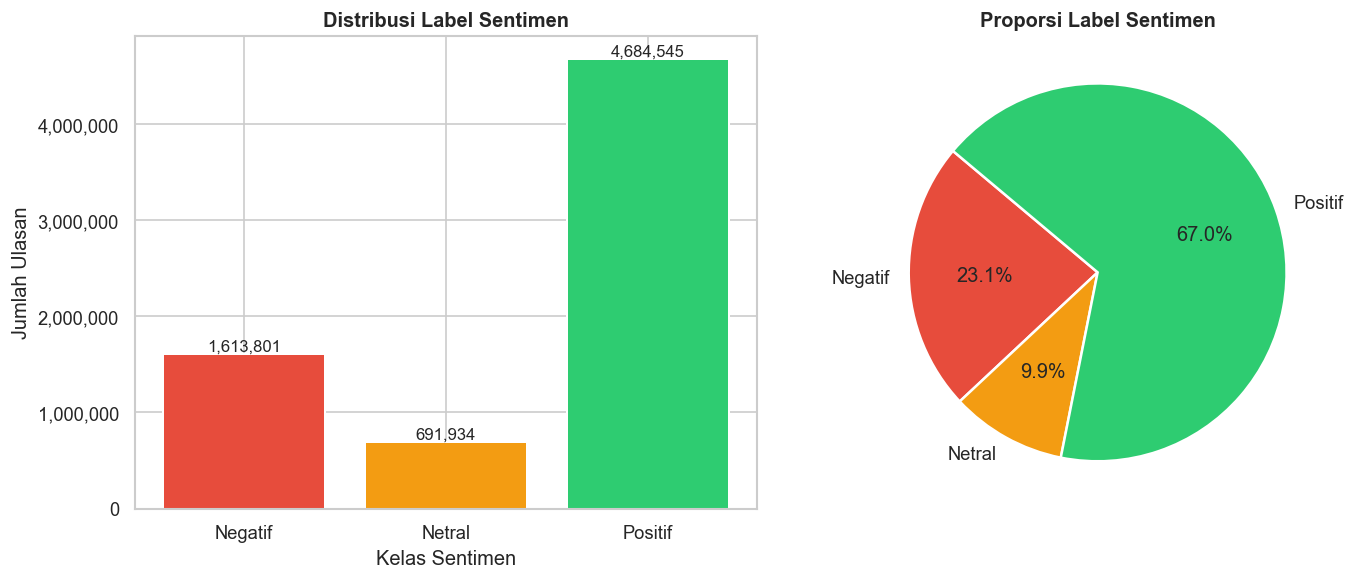

Gambar disimpan: 01_distribusi_sentimen.png


In [5]:
LABEL_MAP  = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
WARNA_SENTIMEN = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}

df['sentiment_label'] = df['sentiment'].map(LABEL_MAP)

dist = df['sentiment'].value_counts().sort_index()
dist_pct = (dist / len(df) * 100).round(2)

print("Distribusi sentimen:")
for k, v in dist.items():
    print(f"  {LABEL_MAP[k]:8s} (label {k}) : {v:>7,}  ({dist_pct[k]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = [WARNA_SENTIMEN[k] for k in dist.index]
bars = axes[0].bar(
    [LABEL_MAP[k] for k in dist.index],
    dist.values,
    color=colors, edgecolor='white', linewidth=1.2
)
axes[0].set_title('Distribusi Label Sentimen', fontweight='bold')
axes[0].set_xlabel('Kelas Sentimen')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(
    dist.values,
    labels=[LABEL_MAP[k] for k in dist.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Label Sentimen', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '01_distribusi_sentimen.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 01_distribusi_sentimen.png")

## 3. Tren Ulasan per Waktu

Lihat bagaimana volume ulasan tumbuh dari 2005 sampai 2019, lalu turun di 2020 (COVID), dan belum kembali normal di 2022 (data kemungkinan belum lengkap untuk tahun itu).

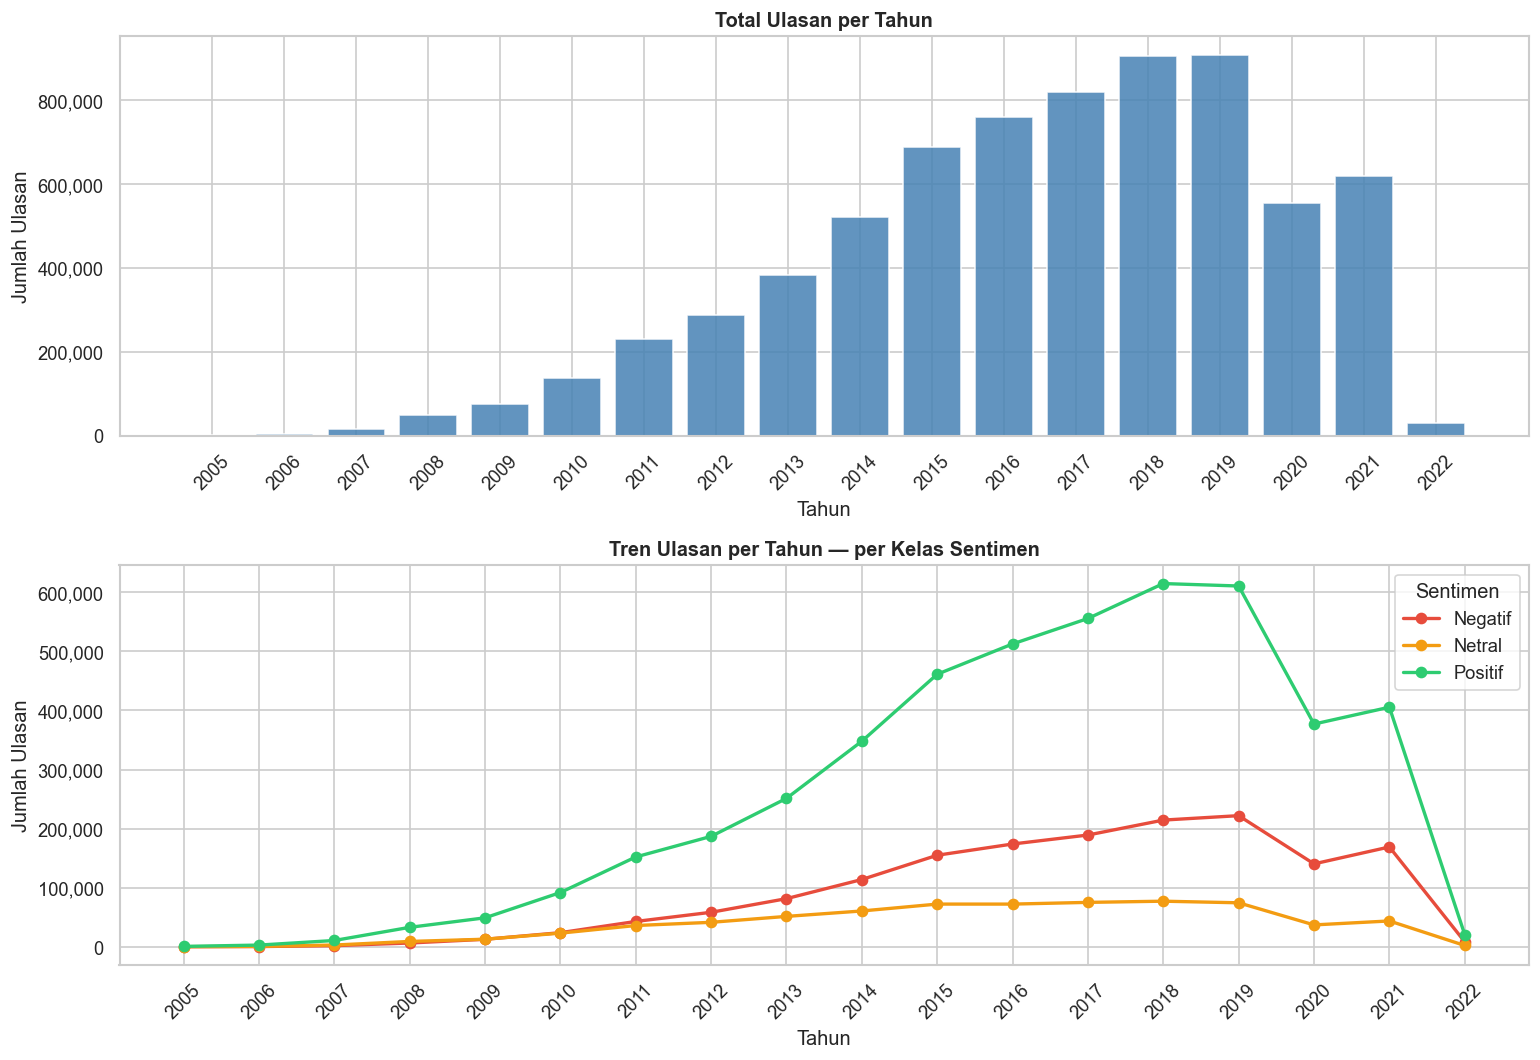

Gambar disimpan: 02_tren_per_tahun.png


In [6]:
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# Filter tahun wajar (Yelp berdiri 2004)
df_time = df[(df['year'] >= 2005) & (df['year'] <= 2022)].copy()

# Ulasan per tahun, dipecah per sentimen
yearly = df_time.groupby(['year', 'sentiment']).size().reset_index(name='count')
yearly['sentiment_label'] = yearly['sentiment'].map(LABEL_MAP)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Plot 1: total ulasan per tahun
total_per_year = df_time.groupby('year').size()
axes[0].bar(total_per_year.index, total_per_year.values,
            color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Total Ulasan per Tahun', fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_xticks(sorted(df_time['year'].unique()))
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: tren per kelas sentimen
for sentiment_val, label in LABEL_MAP.items():
    subset = yearly[yearly['sentiment'] == sentiment_val]
    axes[1].plot(subset['year'], subset['count'],
                 marker='o', label=label,
                 color=WARNA_SENTIMEN[sentiment_val], linewidth=2)
axes[1].set_title('Tren Ulasan per Tahun — per Kelas Sentimen', fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah Ulasan')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Sentimen')
axes[1].set_xticks(sorted(df_time['year'].unique()))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '02_tren_per_tahun.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 02_tren_per_tahun.png")

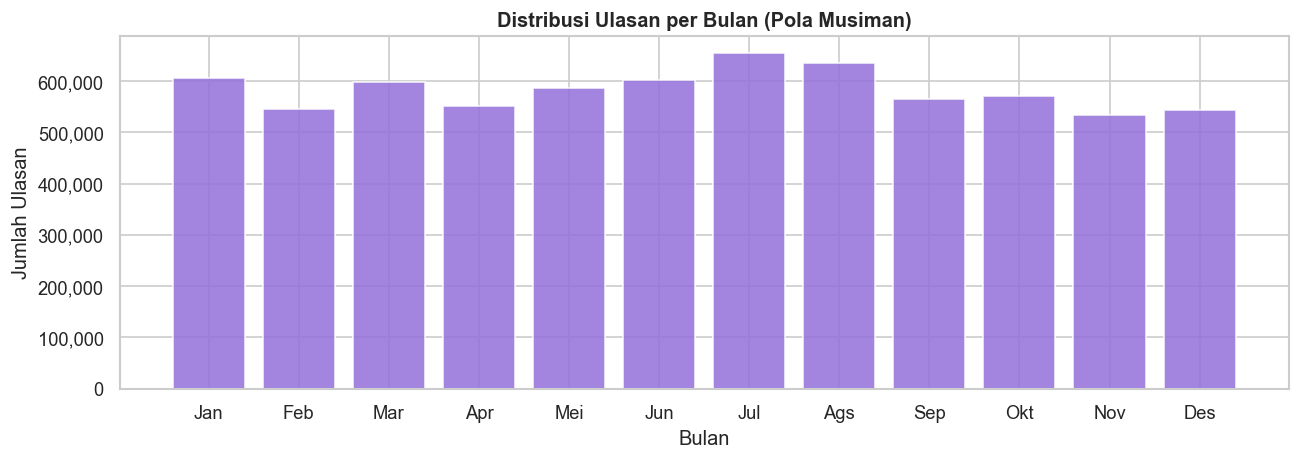

Gambar disimpan: 03_distribusi_per_bulan.png


In [7]:
# Distribusi ulasan per bulan (musiman)
NAMA_BULAN = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']

monthly_total = df_time.groupby('month').size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly_total.index, monthly_total.values,
       color='mediumpurple', alpha=0.85, edgecolor='white')
ax.set_title('Distribusi Ulasan per Bulan (Pola Musiman)', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Ulasan')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(NAMA_BULAN)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '03_distribusi_per_bulan.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 03_distribusi_per_bulan.png")

## 4. Panjang Teks Review

Hipotesis: review negatif cenderung lebih panjang karena orang yang kecewa biasanya menjelaskan lebih detail. Kita verifikasi dengan distribusi dan boxplot.

Statistik panjang teks:
       text_len_char  text_len_word
count     6990280.00     6990280.00
mean          567.76         104.78
std           527.26          97.92
min             1.00           1.00
25%           229.00          42.00
50%           406.00          75.00
75%           720.00         133.00
max          5000.00        1070.00


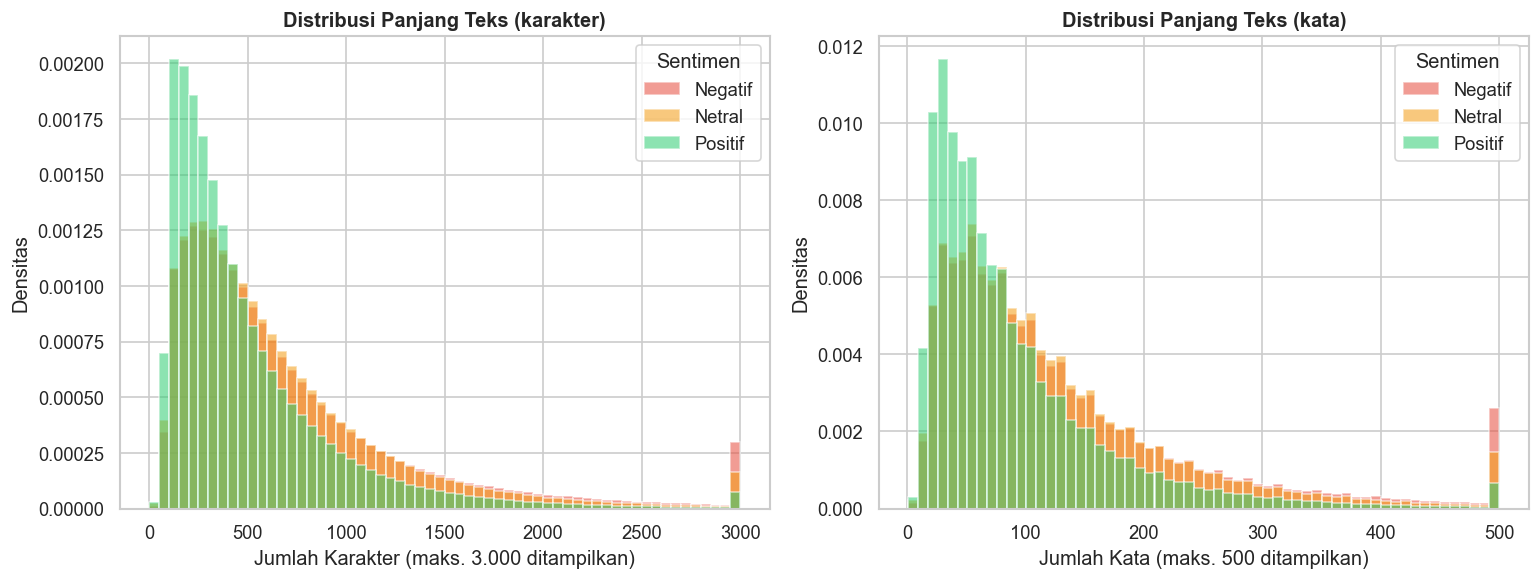

Gambar disimpan: 04_panjang_teks.png


In [8]:
df['text_len_char'] = df['text'].str.len()
df['text_len_word'] = df['text'].str.split().str.len()

print("Statistik panjang teks:")
print(df[['text_len_char', 'text_len_word']].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribusi panjang karakter per sentimen
for s_val, s_label in LABEL_MAP.items():
    subset = df[df['sentiment'] == s_val]['text_len_char']
    # Cap di 3000 agar visualisasi tidak terlalu melebar
    subset_cap = subset.clip(upper=3000)
    axes[0].hist(subset_cap, bins=60, alpha=0.55,
                 label=s_label, color=WARNA_SENTIMEN[s_val], density=True)
axes[0].set_title('Distribusi Panjang Teks (karakter)', fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter (maks. 3.000 ditampilkan)')
axes[0].set_ylabel('Densitas')
axes[0].legend(title='Sentimen')

# Distribusi panjang kata per sentimen
for s_val, s_label in LABEL_MAP.items():
    subset = df[df['sentiment'] == s_val]['text_len_word']
    subset_cap = subset.clip(upper=500)
    axes[1].hist(subset_cap, bins=60, alpha=0.55,
                 label=s_label, color=WARNA_SENTIMEN[s_val], density=True)
axes[1].set_title('Distribusi Panjang Teks (kata)', fontweight='bold')
axes[1].set_xlabel('Jumlah Kata (maks. 500 ditampilkan)')
axes[1].set_ylabel('Densitas')
axes[1].legend(title='Sentimen')

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '04_panjang_teks.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 04_panjang_teks.png")

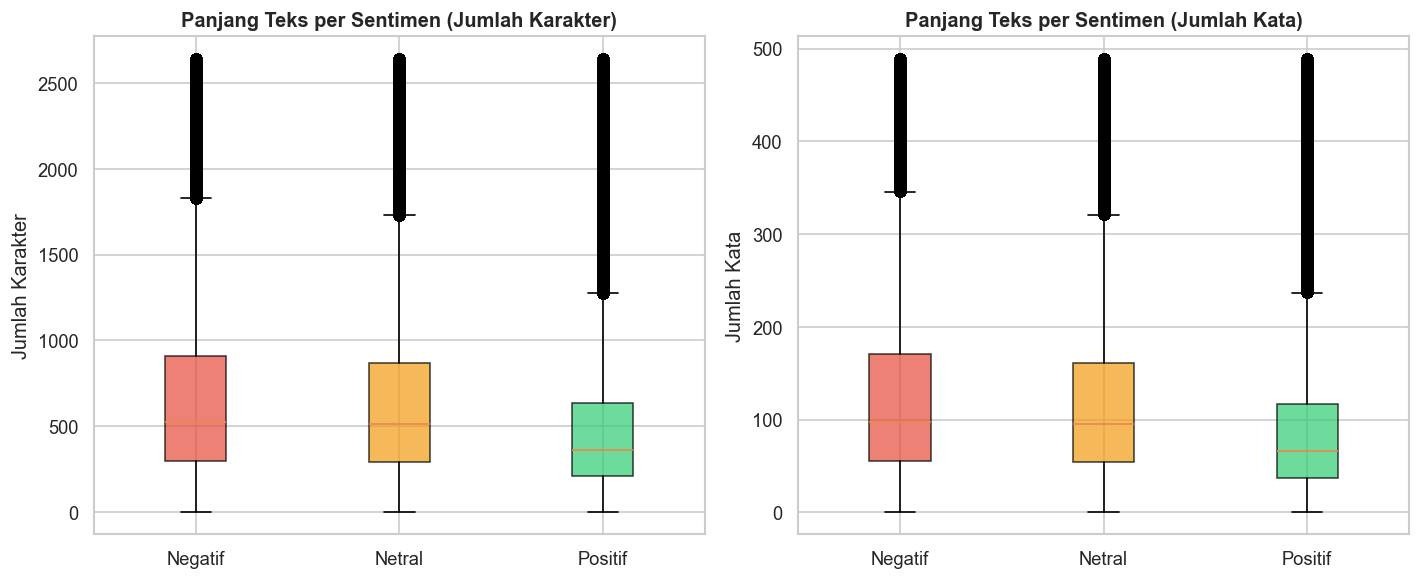

Gambar disimpan: 05_boxplot_panjang_teks.png

Rata-rata panjang teks per kelas sentimen:
                 text_len_char  text_len_word
sentiment_label                              
Negatif                 716.20         134.10
Netral                  669.20         124.20
Positif                 501.60          91.80


In [9]:
# Boxplot rata-rata panjang teks per kelas sentimen
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in [
    (axes[0], 'text_len_char', 'Jumlah Karakter'),
    (axes[1], 'text_len_word', 'Jumlah Kata'),
]:
    data_per_kelas = [
        df[df['sentiment'] == s][col].clip(upper=df[col].quantile(0.99))
        for s in [0, 1, 2]
    ]
    bp = ax.boxplot(data_per_kelas, patch_artist=True,
                    labels=[LABEL_MAP[s] for s in [0, 1, 2]])
    for patch, s in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(WARNA_SENTIMEN[s])
        patch.set_alpha(0.7)
    ax.set_title(f'Panjang Teks per Sentimen ({label})', fontweight='bold')
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '05_boxplot_panjang_teks.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 05_boxplot_panjang_teks.png")

# Rata-rata per kelas
print("\nRata-rata panjang teks per kelas sentimen:")
print(df.groupby('sentiment_label')[['text_len_char', 'text_len_word']].mean().round(1).to_string())

## 5. Kategori Bisnis

Kolom `categories` berisi list kategori dipisah koma per baris, jadi kita perlu di-explode dulu sebelum bisa dihitung frekuensinya.

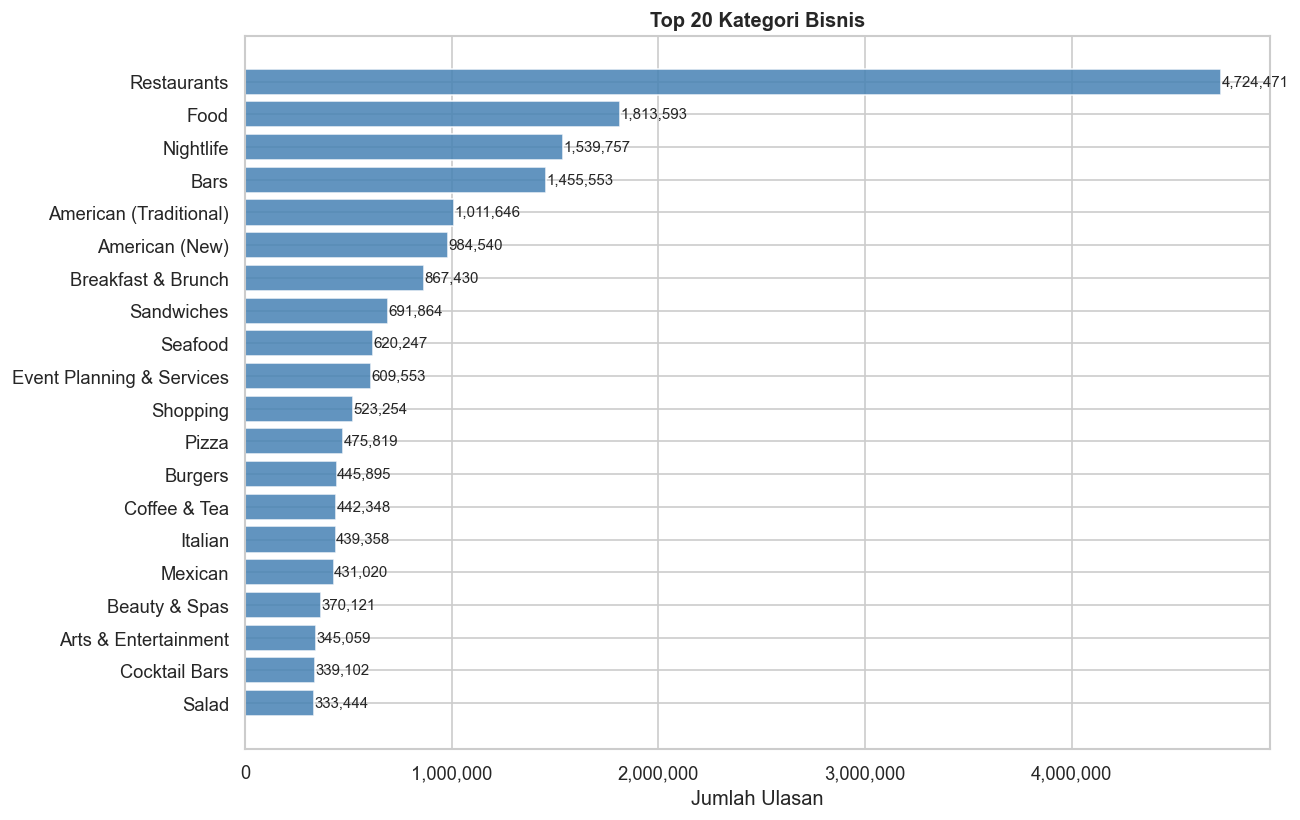

Gambar disimpan: 06_top20_kategori.png


In [10]:
cat_series = df['categories'].dropna().str.split(', ')
all_cats = [cat.strip() for sublist in cat_series for cat in sublist]
cat_counter = Counter(all_cats)

top_cats = pd.DataFrame(cat_counter.most_common(20), columns=['kategori', 'jumlah'])

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_cats['kategori'][::-1], top_cats['jumlah'][::-1],
               color='steelblue', alpha=0.85)
ax.set_title('Top 20 Kategori Bisnis', fontweight='bold')
ax.set_xlabel('Jumlah Ulasan')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# gunakan lebar bar aktual agar label tidak salah posisi/nilai
for bar in bars:
    val = int(bar.get_width())
    ax.text(val + 1000, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '06_top20_kategori.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 06_top20_kategori.png")

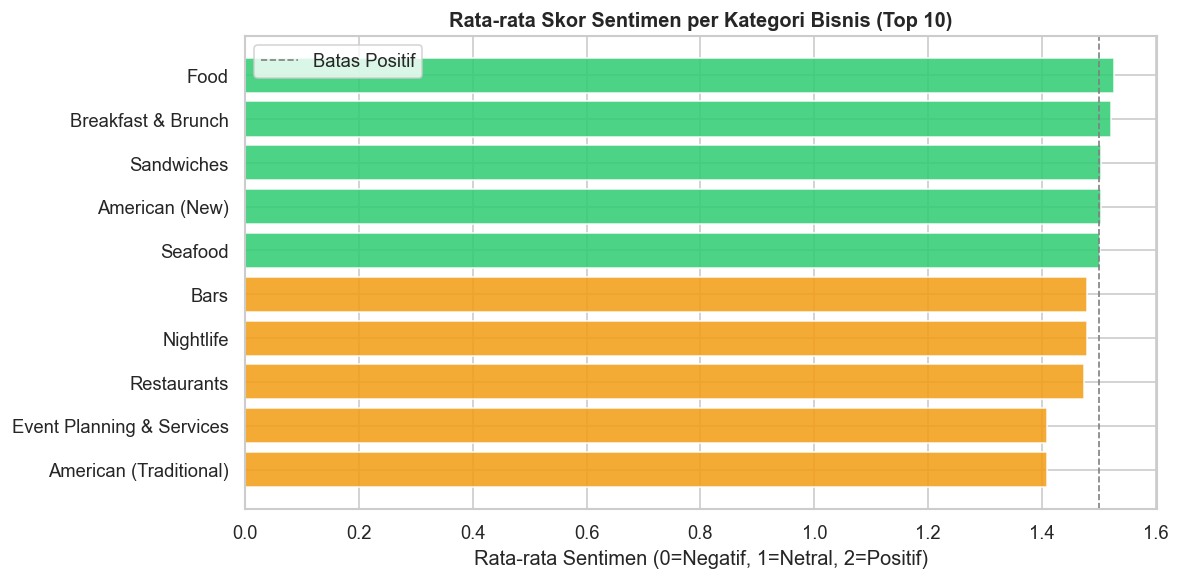

Gambar disimpan: 07_sentimen_per_kategori.png


In [11]:
# Sentimen rata-rata untuk top 10 kategori utama
TOP10_CATS = [c for c, _ in cat_counter.most_common(10)]

# Tandai tiap review apakah masuk kategori tsb (explode approach)
rows = []
for _, row in df[['sentiment', 'categories']].dropna().iterrows():
    for cat in row['categories'].split(', '):
        cat = cat.strip()
        if cat in TOP10_CATS:
            rows.append({'kategori': cat, 'sentiment': row['sentiment']})

df_cat_sent = pd.DataFrame(rows)
cat_sent_avg = df_cat_sent.groupby('kategori')['sentiment'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_cat = ['#2ecc71' if v >= 1.5 else '#f39c12' if v >= 1.0 else '#e74c3c'
              for v in cat_sent_avg.values]
ax.barh(cat_sent_avg.index, cat_sent_avg.values, color=colors_cat, alpha=0.85)
ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, label='Batas Positif')
ax.set_title('Rata-rata Skor Sentimen per Kategori Bisnis (Top 10)', fontweight='bold')
ax.set_xlabel('Rata-rata Sentimen (0=Negatif, 1=Netral, 2=Positif)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '07_sentimen_per_kategori.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 07_sentimen_per_kategori.png")

## 6. Distribusi Geografis

Dataset Yelp mencakup kota-kota di AS dan sebagian Kanada (terlihat dari kode state "AB" = Alberta). Pennsylvania (PA) mendominasi karena ada banyak kota besar seperti Philadelphia di sana.

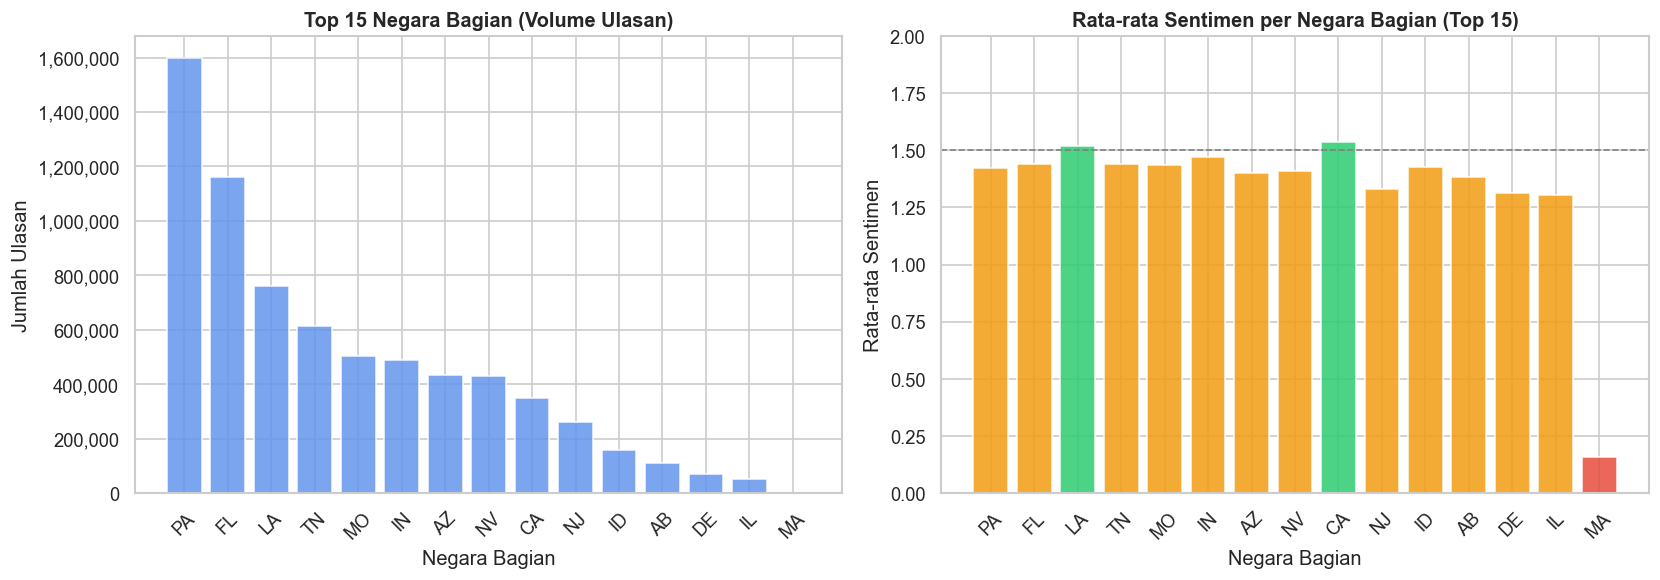

Gambar disimpan: 08_analisis_geografis.png


In [12]:
# Top 15 negara bagian berdasarkan volume ulasan
top_states = df['state'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: volume ulasan
axes[0].bar(top_states.index, top_states.values,
            color='cornflowerblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 15 Negara Bagian (Volume Ulasan)', fontweight='bold')
axes[0].set_xlabel('Negara Bagian')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

# Bar: rata-rata sentimen per state (top 15)
state_sent_avg = df[df['state'].isin(top_states.index)] \
    .groupby('state')['sentiment'].mean() \
    .reindex(top_states.index)

colors_state = ['#2ecc71' if v >= 1.5 else '#f39c12' if v >= 1.0 else '#e74c3c'
                for v in state_sent_avg.values]
axes[1].bar(state_sent_avg.index, state_sent_avg.values,
            color=colors_state, alpha=0.85, edgecolor='white')
axes[1].axhline(y=1.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Rata-rata Sentimen per Negara Bagian (Top 15)', fontweight='bold')
axes[1].set_xlabel('Negara Bagian')
axes[1].set_ylabel('Rata-rata Sentimen')
axes[1].set_ylim(0, 2)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '08_analisis_geografis.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 08_analisis_geografis.png")

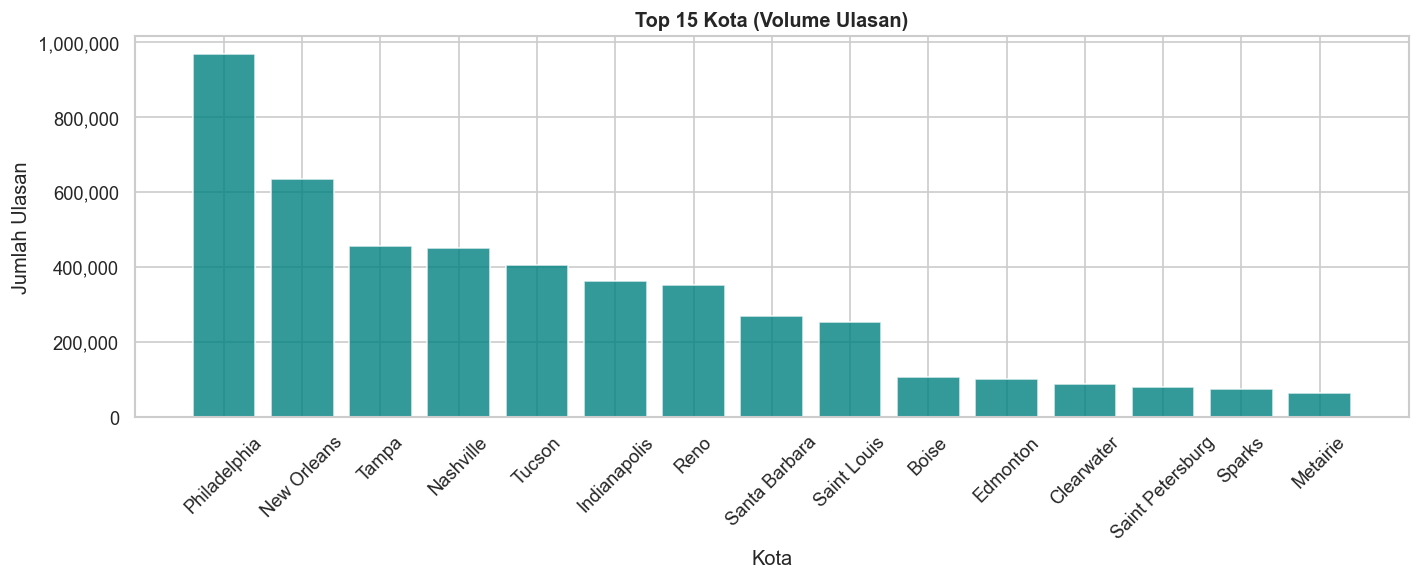

Gambar disimpan: 09_top15_kota.png


In [13]:
# Top 15 kota berdasarkan volume ulasan
top_cities = df['city'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_cities.index, top_cities.values,
       color='teal', alpha=0.8, edgecolor='white')
ax.set_title('Top 15 Kota (Volume Ulasan)', fontweight='bold')
ax.set_xlabel('Kota')
ax.set_ylabel('Jumlah Ulasan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '09_top15_kota.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 09_top15_kota.png")

## 7. Perilaku User

User diklasifikasikan berdasarkan total review yang pernah mereka tulis: Casual (1–10), Active (11–50), Power (>50). Menarik untuk dilihat apakah Power users cenderung lebih kritis atau lebih positif.

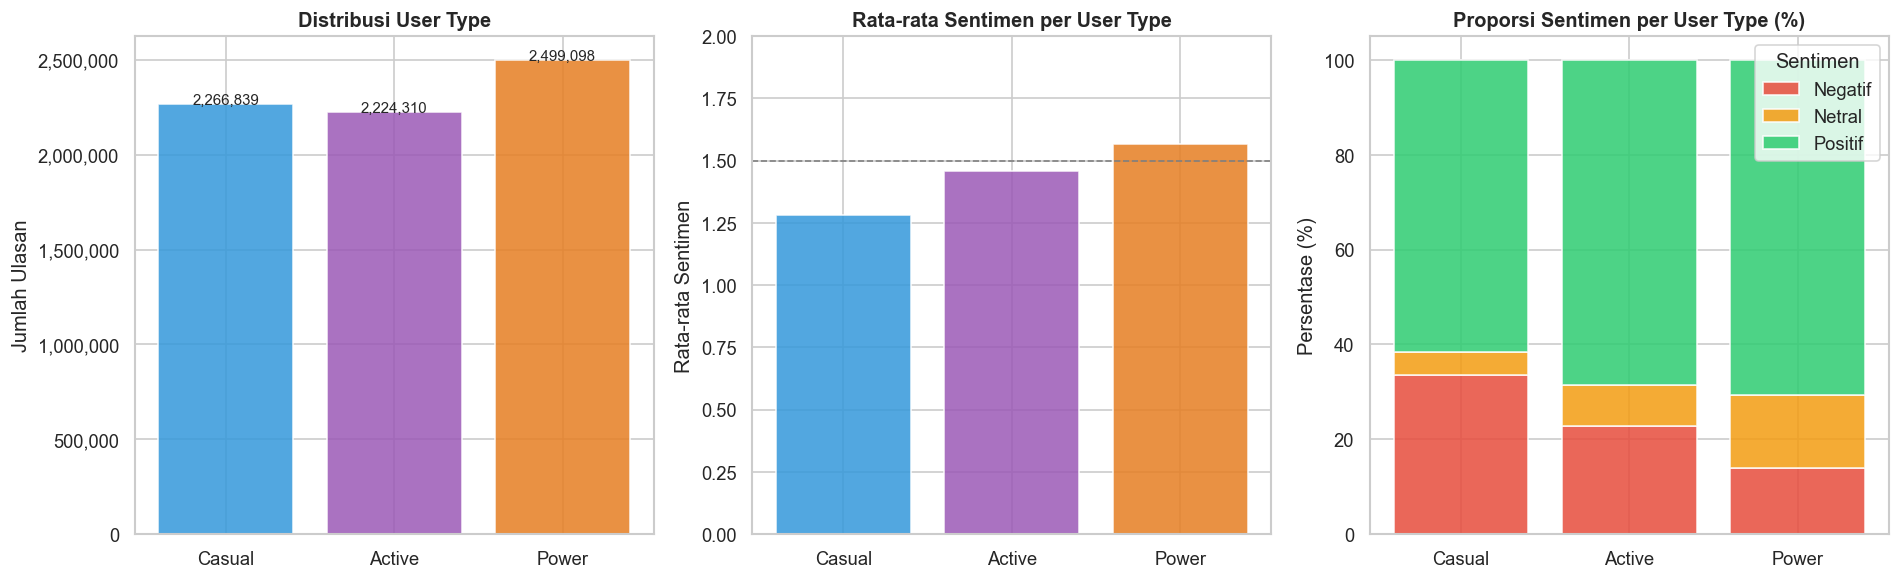

Gambar disimpan: 10_analisis_user_type.png


In [14]:
df_user = df.dropna(subset=['user_type'])

user_type_order = ['Casual', 'Active', 'Power']
user_colors     = {'Casual': '#3498db', 'Active': '#9b59b6', 'Power': '#e67e22'}

# Distribusi user_type
user_dist = df_user['user_type'].value_counts().reindex(user_type_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: distribusi user_type
bars = axes[0].bar(
    user_dist.index, user_dist.values,
    color=[user_colors[u] for u in user_dist.index],
    edgecolor='white', alpha=0.85
)
axes[0].set_title('Distribusi User Type', fontweight='bold')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, user_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=9)

# Bar: rata-rata sentimen per user_type
user_sent = df_user.groupby('user_type')['sentiment'].mean().reindex(user_type_order)
axes[1].bar(
    user_sent.index, user_sent.values,
    color=[user_colors[u] for u in user_sent.index],
    edgecolor='white', alpha=0.85
)
axes[1].axhline(y=1.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Rata-rata Sentimen per User Type', fontweight='bold')
axes[1].set_ylabel('Rata-rata Sentimen')
axes[1].set_ylim(0, 2)

# Stacked bar: proporsi kelas sentimen per user_type
user_sent_prop = df_user.groupby(['user_type', 'sentiment_label']).size().unstack(fill_value=0)
user_sent_prop = user_sent_prop.reindex(user_type_order)
user_sent_prop_pct = user_sent_prop.div(user_sent_prop.sum(axis=1), axis=0) * 100

label_order = ['Negatif', 'Netral', 'Positif']
bottom = np.zeros(len(user_type_order))
color_map = {'Negatif': '#e74c3c', 'Netral': '#f39c12', 'Positif': '#2ecc71'}
for lbl in label_order:
    if lbl in user_sent_prop_pct.columns:
        vals = user_sent_prop_pct[lbl].values
        axes[2].bar(user_type_order, vals, bottom=bottom,
                    label=lbl, color=color_map[lbl], alpha=0.85)
        bottom += vals
axes[2].set_title('Proporsi Sentimen per User Type (%)', fontweight='bold')
axes[2].set_ylabel('Persentase (%)')
axes[2].legend(title='Sentimen', loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '10_analisis_user_type.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 10_analisis_user_type.png")

## 8. Korelasi Fitur Numerik

Korelasi `stars`–`sentiment` = 0.95 wajar karena sentiment memang di-derive dari stars. Yang lebih menarik: `text_len_word` berkorelasi negatif dengan sentiment (review negatif lebih panjang), dan `average_stars` user berkorelasi moderat dengan rating yang dia beri.

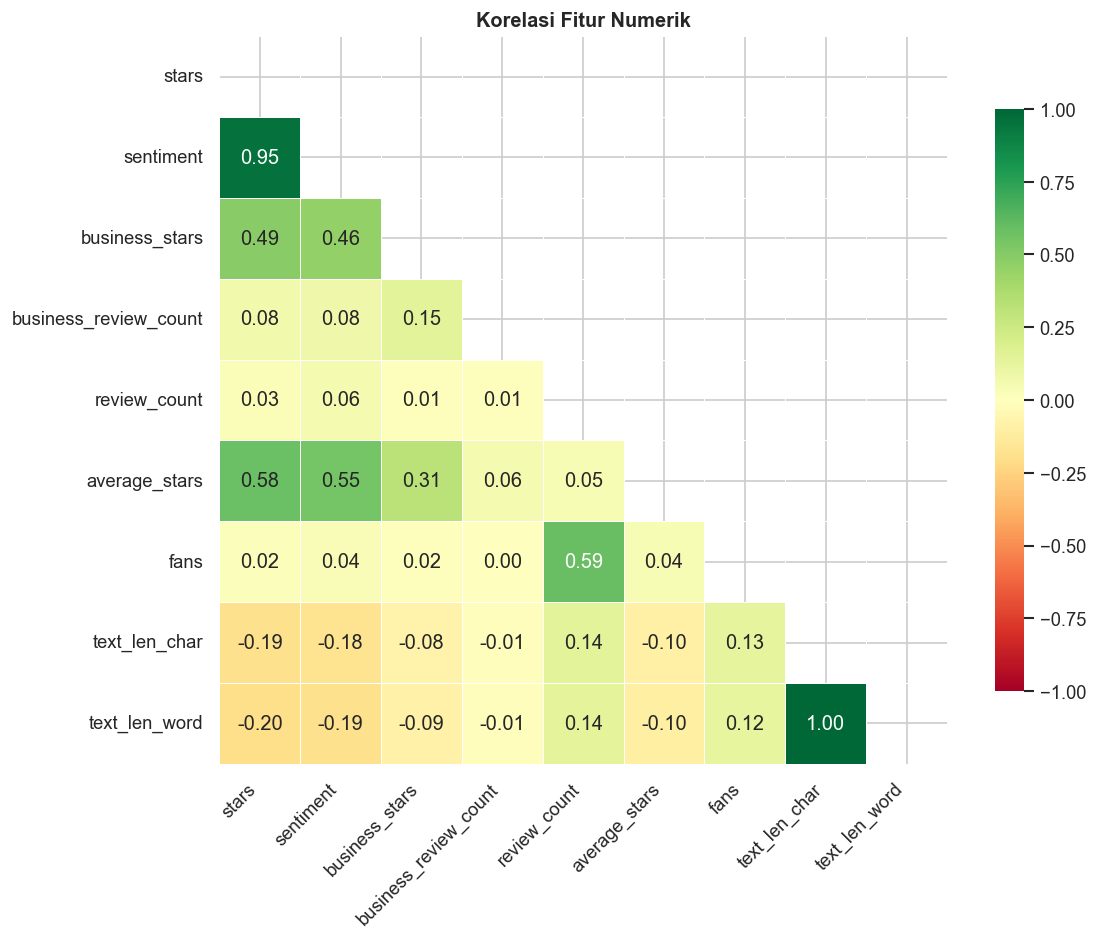

Gambar disimpan: 11_korelasi_numerik.png

Korelasi dengan 'sentiment' (diurutkan):
stars                    0.95
average_stars            0.55
business_stars           0.46
text_len_word           -0.19
text_len_char           -0.18
business_review_count    0.08
review_count             0.06
fans                     0.04


In [15]:
NUM_COLS = ['stars', 'sentiment', 'business_stars', 'business_review_count',
            'review_count', 'average_stars', 'fans', 'text_len_char', 'text_len_word']

# Force-cast semua kolom ke numerik (Parquet dari Spark menyimpan beberapa kolom sebagai object)
df_num = df[NUM_COLS].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Korelasi Fitur Numerik', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '11_korelasi_numerik.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 11_korelasi_numerik.png")

# Korelasi tertinggi dengan sentiment
print("\nKorelasi dengan 'sentiment' (diurutkan):")
corr_sent = corr_matrix['sentiment'].drop('sentiment').sort_values(key=abs, ascending=False)
print(corr_sent.to_string())

## 9. Word Cloud per Kelas Sentimen

Kata-kata yang sering muncul di tiap kelas — ini berguna untuk memastikan stopword sudah cukup dan ada kata diskriminatif yang jelas antar kelas.

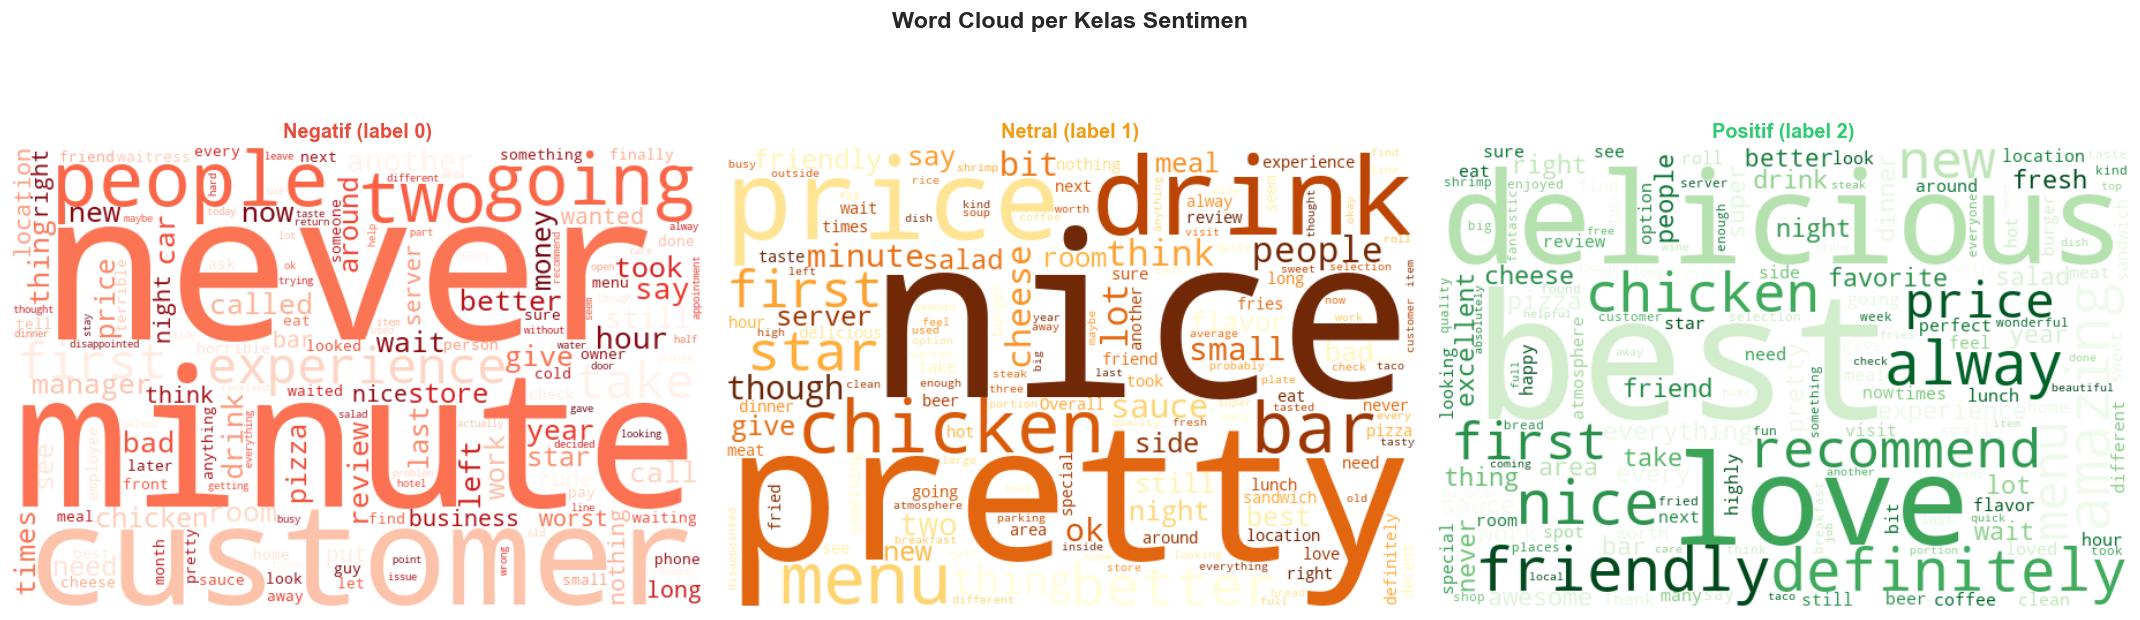

Gambar disimpan: 12_wordcloud_*.png


In [16]:
EXTRA_STOPWORDS = {
    # terlalu umum di semua kelas — tidak diskriminatif
    'will', 'service', 'order', 'ordered', 'food', 'place', 'restaurant',
    'one', 'get', 'got', 'us', 'also', 'back', 'would', 'time', 'went',
    'go', 'well', 'even', 'made', 'much', 'good', 'great', 'like', 'just',
    'came', 'said', 'told', 'make', 'come', 'asked', 'really', 'table',
    'staff', 'try', 'tried', 'little', 'way', 'know', 'want', 'day',
}
STOPWORDS_ALL = STOPWORDS.union(EXTRA_STOPWORDS)

WC_COLORS = {0: 'Reds', 1: 'YlOrBr', 2: 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Cloud per Kelas Sentimen', fontsize=14, fontweight='bold')

for s_val, s_label in LABEL_MAP.items():
    texts = df[df['sentiment'] == s_val]['text'].dropna().sample(
        n=min(5000, df[df['sentiment'] == s_val].shape[0]), random_state=42
    )
    corpus = ' '.join(texts.values)

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=150,
        stopwords=STOPWORDS_ALL,
        colormap=WC_COLORS[s_val],
        collocations=False
    ).generate(corpus)

    axes[s_val].imshow(wc, interpolation='bilinear')
    axes[s_val].axis('off')
    axes[s_val].set_title(f'{s_label} (label {s_val})', fontweight='bold',
                          color=list(WARNA_SENTIMEN.values())[s_val])

    wc.to_file(os.path.join(PATH_FIG, f'12_wordcloud_{s_label.lower()}.png'))

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '12_wordcloud_semua.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 12_wordcloud_*.png")

## 10. Ringkasan Temuan EDA

In [17]:
print("=" * 65)
print("RINGKASAN TEMUAN EDA — 02_eda.ipynb")
print("=" * 65)

print(f"\n[1] Dataset      : {len(df):,} baris, {len(df.columns)} kolom")

print("\n[2] Distribusi sentimen:")
for k in [0, 1, 2]:
    n = (df['sentiment'] == k).sum()
    print(f"      {LABEL_MAP[k]:8s}: {n:>7,}  ({n/len(df)*100:.1f}%)")

print(f"\n[3] Rentang waktu: {df['year'].min():.0f} – {df['year'].max():.0f}")

print(f"\n[4] Panjang teks (median kata): "
      f"Negatif={df[df['sentiment']==0]['text_len_word'].median():.0f}, "
      f"Netral={df[df['sentiment']==1]['text_len_word'].median():.0f}, "
      f"Positif={df[df['sentiment']==2]['text_len_word'].median():.0f}")

print(f"\n[5] Top 3 kategori bisnis: "
      + ", ".join([c for c, _ in cat_counter.most_common(3)]))

print(f"\n[6] Top 3 negara bagian  : "
      + ", ".join(df['state'].value_counts().head(3).index.tolist()))

print(f"\n[7] User type dominan    : {df_user['user_type'].value_counts().idxmax()}")

print(f"\n[8] Gambar tersimpan di  : {PATH_FIG}")

print("\nEDA selesai. Lanjut ke 03_preprocessing.ipynb")

RINGKASAN TEMUAN EDA — 02_eda.ipynb

[1] Dataset      : 6,990,280 baris, 23 kolom

[2] Distribusi sentimen:
      Negatif : 1,613,801  (23.1%)
      Netral  : 691,934  (9.9%)
      Positif : 4,684,545  (67.0%)

[3] Rentang waktu: 2005 – 2022

[4] Panjang teks (median kata): Negatif=98, Netral=95, Positif=66

[5] Top 3 kategori bisnis: Restaurants, Food, Nightlife

[6] Top 3 negara bagian  : PA, FL, LA

[7] User type dominan    : Power

[8] Gambar tersimpan di  : D:\big-data-ai-sentiment\outputs\figures

EDA selesai. Lanjut ke 03_preprocessing.ipynb
